# TP - Détection de Fraude par Arbre de Décision
Méthodologie : CRISP-DM

Dataset : Fraud Detection Dataset.csv

Objectif : Implémenter et comprendre (via DecisionTreeClassifier sklearn) pour prédire si une transaction de carte de crédit est frauduleuse.


## Problématique métier

FraudGuard Solutions est une entreprise spécialisée dans les solutions d'intelligence artificielle pour le secteur financier. Récemment, une grande banque nous a contactés pour un problème précis :

Chaque jour, cette banque traite des millions de transactions par carte de crédit. Ses méthodes actuelles de détection de fraude génèrent trop d'erreurs dans les deux sens : des transactions légitimes sont bloquées à tort (faux positifs) et des fraudes passent entre les mailles du filet (faux négatifs). Ces erreurs coûtent cher financièrement et créent beaucoup d'insatisfaction chez leurs clients.

La banque recherche donc une solution automatisée qui pourrait aider leurs analystes à prédire si une transaction est frauduleuse ou non, en se basant sur les caractéristiques de chaque transaction. La solution doit être fiable, facile à comprendre pour les équipes, et capable de réduire le nombre d'erreurs de détection.

Notre proposition : développer un modèle d'arbre de décision qui analysera les données de transaction et donnera une prédiction claire pour chaque cas.

## Phase 0 — Installation et Imports

Importez toutes les librairies nécessaires pour ce TP.

> **Librairies attendues :** `numpy`, `pandas`, `matplotlib`, `seaborn`, et les modules scikit-learn suivants : `datasets`, `model_selection`, `tree`, `metrics`.

In [173]:
# TODO : Importez les librairies nécessaires pour le TP
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, recall_score, precision_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score,accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# TODO : Activez les réglages d'affichage si besoin (ex. : warnings, affichage pandas)
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Imports réussis")


Imports réussis


## Phase 1 — Business Understanding

### Contexte
Vous êtes data scientist chez FraudGuard Solutions.

### Objectif
Développer un modèle d'arbre de décision capable de prédire si une transaction de carte de crédit est frauduleuse ou légitime à partir de ses caractéristiques.

### Questions métier à résoudre

1. Peut-on prédire de manière fiable la nature frauduleuse d'une transaction ?
2. Quelles sont les caractéristiques de transaction les plus importantes pour cette prédiction ?
3. Le modèle peut-il aider à réduire les pertes liées à la fraude et l'insatisfaction client ?

### Traduction en problème ML

| Élément | Valeur |
|---------|--------|
| **Type de problème** | Classification binaire (avec déséquilibre de classes) |
| **Variable cible Y** | `Fraudulent` (0 = non-frauduleuse, 1 = frauduleuse) |
| **Variables explicatives X** | Caractéristiques numériques des transactions |
| **Métrique principale** | Précision, Rappel (Recall), F1-Score sur la classe minoritaire (fraude) |

---

> **À compléter :** Reformulez en une phrase la question métier que vous allez résoudre avec l'arbre de décision.

**Votre réponse ici :**

_« Comment prédire de manière fiable si une transaction est frauduleuse en analysant ses caractéristiques ? »_

## Phase 2 — Data Understanding

### 2.1 Chargement des données

Chargez le dataset Breast Cancer depuis scikit-learn.

In [174]:
# TODO : Chargez le dataset Credit Card Fraud (assurez-vous que le fichier creditcard.csv est disponible)
df = pd.read_csv('Fraud Detection Dataset.csv')

df.head(30)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
5,T6,2095,2372.04,ATM Withdrawal,15.0,Desktop,Boston,3,96,14,Credit Card,0
6,T7,4772,544.81,Bill Payment,2.0,Tablet,Boston,3,6,9,UPI,1
7,T8,4092,635.75,ATM Withdrawal,13.0,Tablet,Boston,2,13,10,Debit Card,0
8,T9,2638,2318.87,Bank Transfer,NaN,Mobile,San Francisco,4,110,12,Debit Card,0
9,T10,3169,3656.17,Bill Payment,3.0,Mobile,Chicago,4,66,3,Net Banking,0


### 2.2 Exploration initiale

Faites une première inspection du dataset : dimensions, types, aperçu des données.

In [175]:
# TODO : Faites une copie du dataset pour conserver l'original
df_copy = df.copy()
# TODO : Affichez les premières lignes pour inspection
print(df_copy.head())


  Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
0             T1     4174             1292.76   ATM Withdrawal   
1             T2     4507             1554.58   ATM Withdrawal   
2             T3     1860             2395.02   ATM Withdrawal   
3             T4     2294              100.10     Bill Payment   
4             T5     2130             1490.50      POS Payment   

   Time_of_Transaction Device_Used       Location  \
0                 16.0      Tablet  San Francisco   
1                 13.0      Mobile       New York   
2                  NaN      Mobile            NaN   
3                 15.0     Desktop        Chicago   
4                 19.0      Mobile  San Francisco   

   Previous_Fraudulent_Transactions  Account_Age  \
0                                 0          119   
1                                 4           79   
2                                 3          115   
3                                 4            3   
4                       

In [176]:
# TODO : Affichez la dimension du dataset (nombre de lignes et de colonnes)
print("Dimension du dataset ")
print(df_copy.shape)
# TODO : Affichez les types de chaque colonne
print("Types de chaque colonne ")
print(df_copy.dtypes)

Dimension du dataset 
(51000, 12)
Types de chaque colonne 
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object


### 2.3 Distribution de la variable cible

Analysez la répartition des classes (maligne vs bénigne) pour détecter un éventuel déséquilibre.

In [177]:
# TODO : Calculez le nombre et le pourcentage d'échantillons par classe (non-frauduleuse / frauduleuse)
non_fraude_count = df_copy['Fraudulent'].value_counts()[0]
fraude_count = df_copy['Fraudulent'].value_counts()[1]
total_count = non_fraude_count + fraude_count
non_fraude_pourcentage = (non_fraude_count / total_count) * 100
fraude_pourcentage = (fraude_count / total_count) * 100
# TODO : Affichez ces résultats de manière lisible
print(f"Nombre d'échantillons non-frauduleuses : {non_fraude_count}")
print(f"Nombre d'échantillons frauduleuses : {fraude_count}")
print(f"Pourcentage d'échantillons non-frauduleuses : {non_fraude_pourcentage:.2f}%")
print(f"Pourcentage d'échantillons frauduleuses : {fraude_pourcentage:.2f}%")

Nombre d'échantillons non-frauduleuses : 48490
Nombre d'échantillons frauduleuses : 2510
Pourcentage d'échantillons non-frauduleuses : 95.08%
Pourcentage d'échantillons frauduleuses : 4.92%


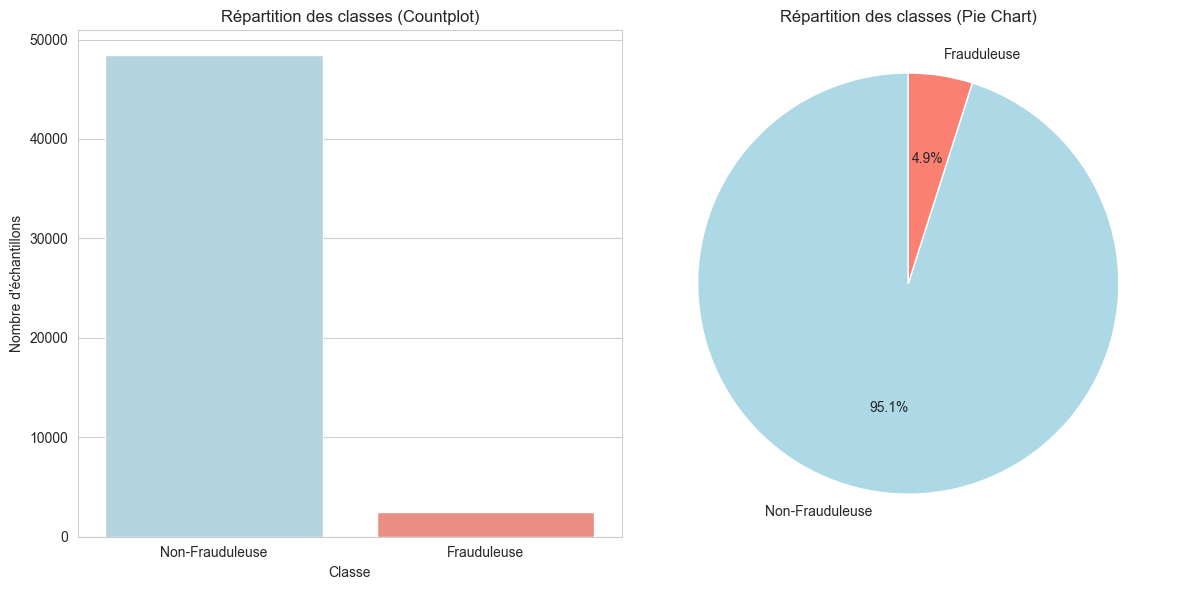

In [178]:
# TODO : Visualisez la distribution des classes avec un graphique adapté (countplot ou pie)
# TODO : Utilisez des labels clairs ('Non-Frauduleuse', 'Frauduleuse') plutôt que les codes 0/1

# Countplot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) 
sns.countplot(x='Fraudulent', data=df_copy, palette=['lightblue','salmon'])
plt.title('Répartition des classes (Countplot)')
plt.xlabel('Classe')
plt.ylabel("Nombre d'échantillons")
plt.xticks([0, 1], ['Non-Frauduleuse', 'Frauduleuse'])

# Pie chart
plt.subplot(1, 2, 2) 
class_distribution = df_copy['Fraudulent'].value_counts()
plt.pie(class_distribution, labels=['Non-Frauduleuse', 'Frauduleuse'], autopct='%1.1f%%', startangle=90, colors=['lightblue','salmon'])
plt.title('Répartition des classes (Pie Chart)')
plt.axis('equal') 

plt.tight_layout()
plt.show()

### 2.4 Analyse des valeurs manquantes

Vérifiez s'il y a des valeurs manquantes dans le dataset avant de continuer.

In [179]:
# TODO : Vérifiez les valeurs manquantes par colonne
# Affichez le nombre de valeurs manquantes par colonne
missing_values = df_copy.isnull().sum()
print("Valeurs manquantes par colonne")
print(missing_values)

# TODO : Affichez uniquement les colonnes qui en contiennent (si applicable)
columns_with_missing_values = missing_values[missing_values > 0]
if not columns_with_missing_values.empty:
    print("\nColonnes avec des valeurs manquantes:")
    print(columns_with_missing_values)
else:
    print("\nAucune valeur manquante dans le dataset.")


Valeurs manquantes par colonne
Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

Colonnes avec des valeurs manquantes:
Transaction_Amount     2520
Time_of_Transaction    2552
Device_Used            2473
Location               2547
Payment_Method         2469
dtype: int64


Imputation des valeurs manquantes

In [180]:
df_copy["Transaction_Amount"].fillna(df_copy["Transaction_Amount"].median(), inplace=True)
df_copy["Device_Used"].fillna(df_copy["Device_Used"].mode()[0], inplace=True)
df_copy["Location"].fillna(df_copy["Location"].mode()[0], inplace=True)
df_copy["Payment_Method"].fillna(df_copy["Payment_Method"].mode()[0],inplace = True)
df_copy["Time_of_Transaction"].fillna(df_copy["Time_of_Transaction"].mode()[0], inplace=True)

Vérification

In [181]:
df_copy.isnull().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

### 2.5 Statistiques descriptives

Analysez les statistiques des variables numériques et identifiez les variations importantes entre les caractéristiques.

> Observez les moyennes, écarts-types et plages de valeurs. Certaines variables ont-elles des échelles très différentes ?

In [182]:
# TODO : Affichez les statistiques descriptives complètes (mean, std, min, max, quartiles)
# TODO : Transposez le résultat si nécessaire pour une meilleure lisibilité
print("Statistiques descriptives")
df_copy.describe().T

Statistiques descriptives


,count,mean,std,min,25%,50%,75%,max
User_ID,51000.0,3005.110176,1153.121107,1000.00,2007.0000,2996.0,4006.0000,4999.0
Transaction_Amount,51000.0,2972.920030,4918.801144,5.03,1333.7875,2524.1,3724.9875,49997.8
Time_of_Transaction,51000.0,11.814235,6.895258,0.00,6.0000,12.0,18.0000,23.0
Previous_Fraudulent_Transactions,51000.0,1.995725,1.415150,0.00,1.0000,2.0,3.0000,4.0
Account_Age,51000.0,60.033902,34.384131,1.00,30.0000,60.0,90.0000,119.0
Number_of_Transactions_Last_24H,51000.0,7.495588,4.020080,1.00,4.0000,7.0,11.0000,14.0
Fraudulent,51000.0,0.049216,0.216320,0.00,0.0000,0.0,0.0000,1.0


_Oui , certains variables ont des échelles très différentes_

### 2.6 Visualisation comparative non-frauduleuse vs frauduleuse

Pour comprendre le pouvoir discriminant des variables, visualisez la distribution de plusieurs caractéristiques **selon la classe cible**.

> C'est une étape clé du Data Understanding : si les distributions des deux classes se chevauchent fortement, la variable sera peu utile pour la classification.

**Caractéristiques suggérées :** `Time_of_Transaction`, `Transaction_Amount`, `Previous_Fraudulent_Transactions`, `Account_Age`, `Number_of_Transactions_Last_24H`

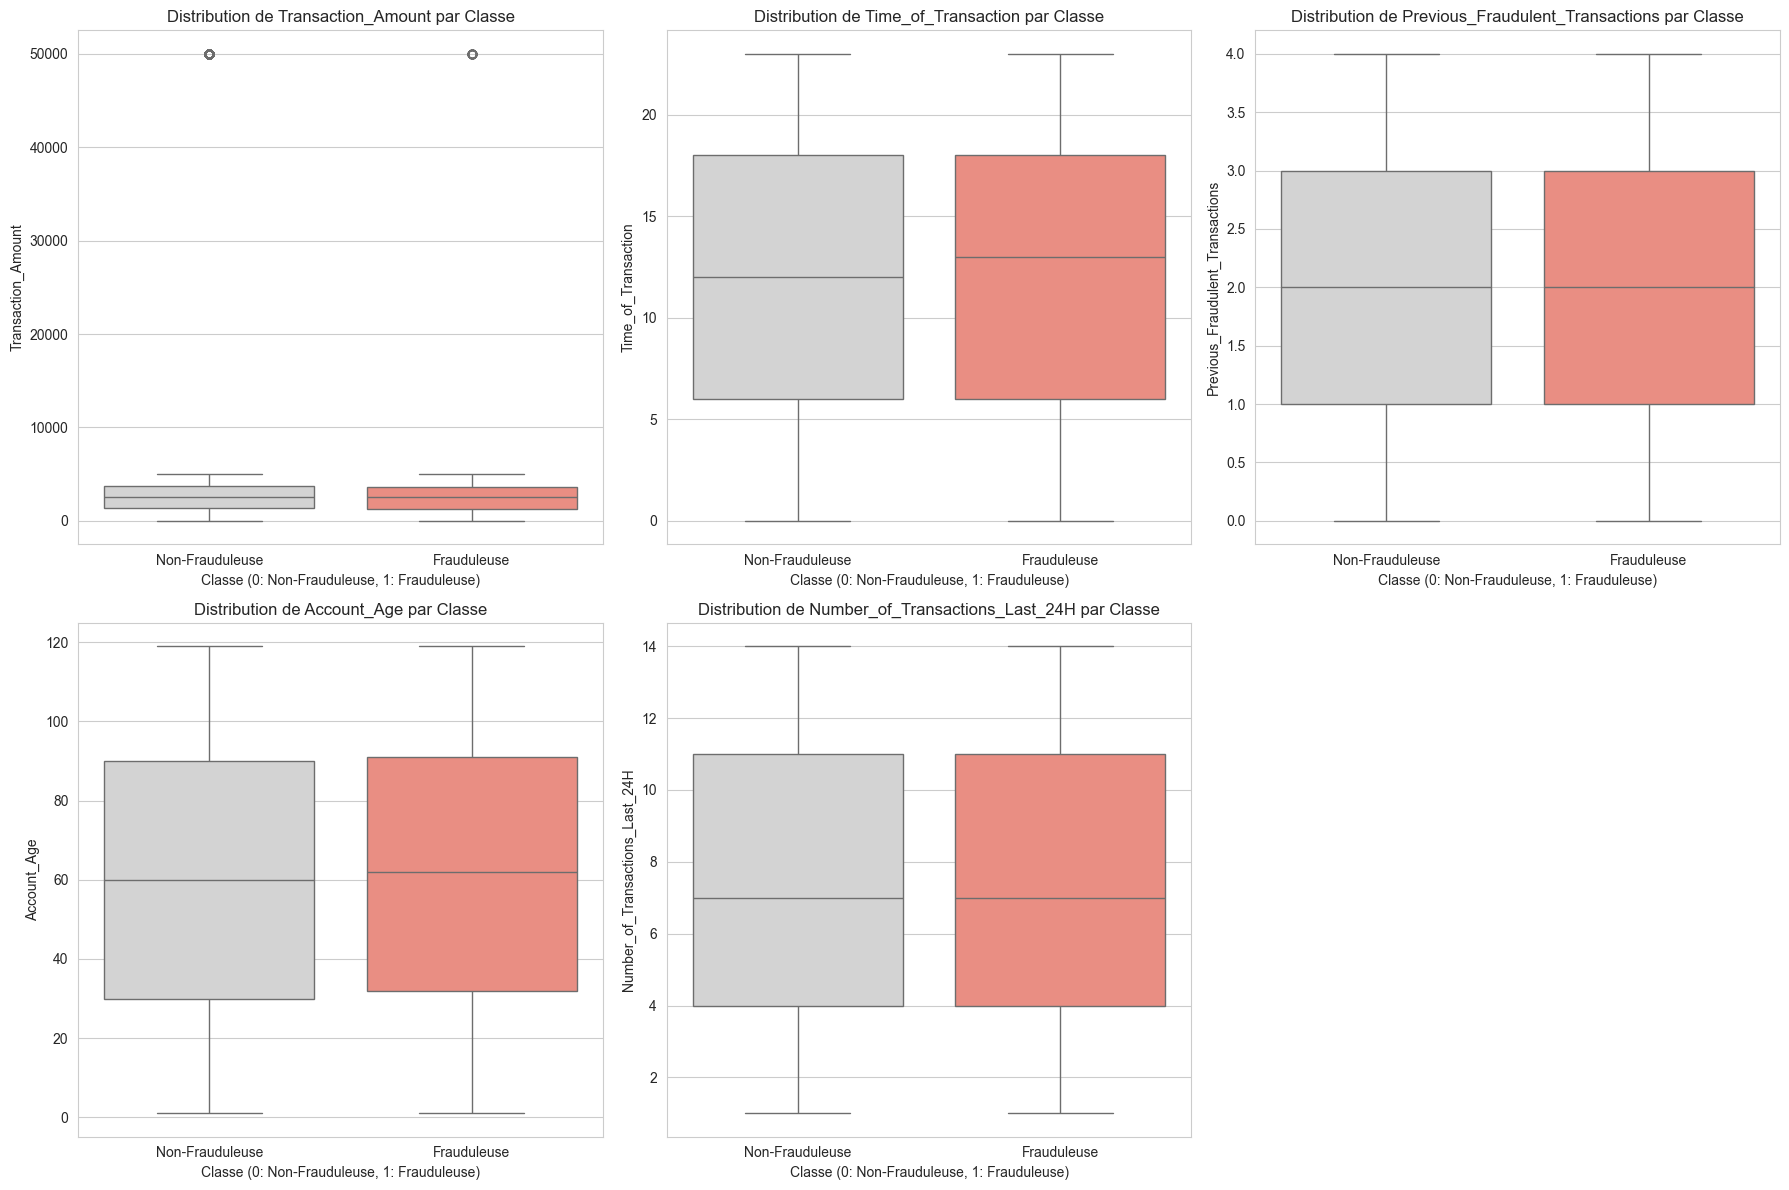

In [183]:
df_num = ['Transaction_Amount', 'Time_of_Transaction','Previous_Fraudulent_Transactions', 'Account_Age','Number_of_Transactions_Last_24H'] 

# TODO : Créez des boxplots comparatifs pour 4 à 6 caractéristiques importantes
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12)) 
axes = axes.flatten()

# TODO : Séparez les boxplots par classe (Non frauduleuse vs Frauduleuse) pour chaque caractéristique
for i, feature in enumerate(df_num):
    sns.boxplot(x='Fraudulent', y=feature, data=df_copy, ax=axes[i], palette=['lightgray', 'salmon'])
    axes[i].set_title(f'Distribution de {feature} par Classe')
    axes[i].set_xlabel('Classe (0: Non-Frauduleuse, 1: Frauduleuse)')
    axes[i].set_ylabel(feature)
    axes[i].set_xticks([0, 1], ['Non-Frauduleuse', 'Frauduleuse'])

# TODO : Organisez les graphiques en grille (ex. : 2 lignes × 3 colonnes)
for j in range(len(df_num), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 2.7 Corrélations

Étudiez les relations entre les variables pour identifier les redondances et les variables fortement liées à la cible.

In [184]:
print("Colonnes du dataset après traitement :")
print(df_copy.columns.tolist())

Colonnes du dataset après traitement :
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


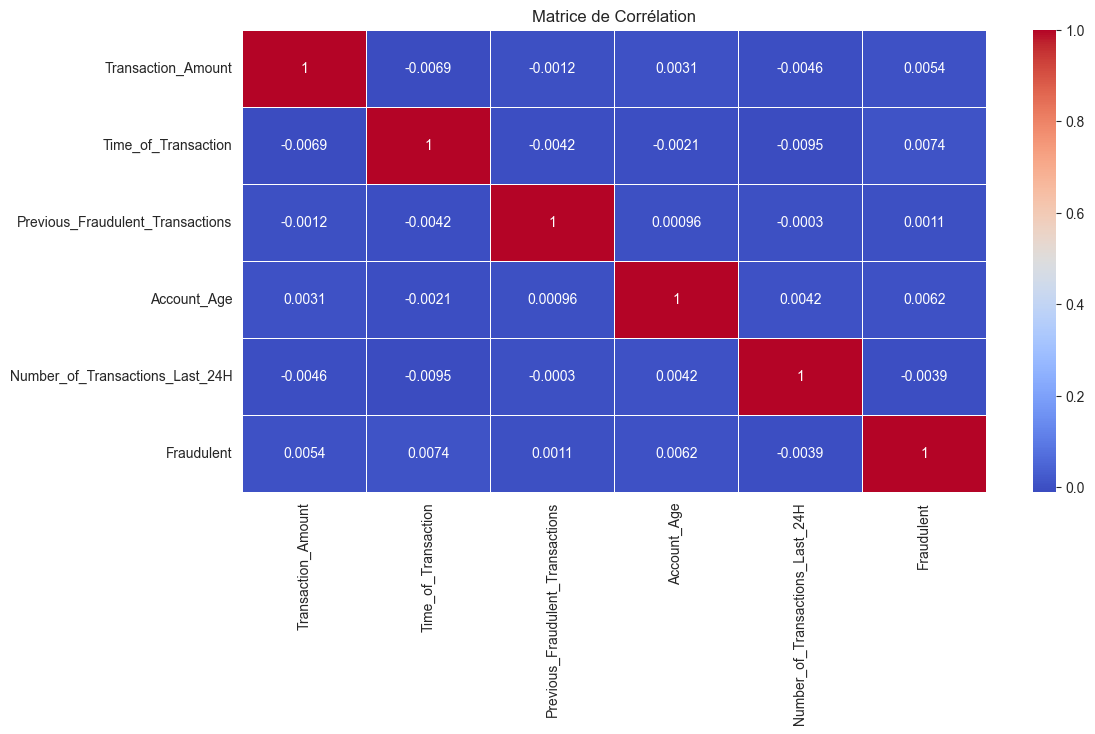

 Corrélations avec 'Fraudulent' (triées par ordre décroissant) 
Time_of_Transaction                 0.007418
Account_Age                         0.006203
Transaction_Amount                  0.005359
Previous_Fraudulent_Transactions    0.001136
Number_of_Transactions_Last_24H    -0.003877
Name: Fraudulent, dtype: float64

 Top 5 corrélations positives 
Time_of_Transaction                 0.007418
Account_Age                         0.006203
Transaction_Amount                  0.005359
Previous_Fraudulent_Transactions    0.001136
Number_of_Transactions_Last_24H    -0.003877
Name: Fraudulent, dtype: float64

 Top 5 corrélations négatives 
Time_of_Transaction                 0.007418
Account_Age                         0.006203
Transaction_Amount                  0.005359
Previous_Fraudulent_Transactions    0.001136
Number_of_Transactions_Last_24H    -0.003877
Name: Fraudulent, dtype: float64


In [185]:
# TODO : Calculez et visualisez la matrice de corrélation (heatmap)
# Sélectionnez uniquement les colonnes numériques pour éviter l'erreur ValueError
correlation_matrix = df_copy.select_dtypes(include=[np.number]).drop(columns=['User_ID']).corr()

plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.show()

# TODO : Identifiez les variables les plus corrélées à 'Fraudulent'
print(" Corrélations avec 'Fraudulent' (triées par ordre décroissant) ")
fraud_corr = correlation_matrix['Fraudulent'].drop('Fraudulent').sort_values(ascending=False)
print(fraud_corr)

# Commentez les corrélations fortes entre les variables explicatives (multicolinéarité)
print("\n Top 5 corrélations positives ")
print(fraud_corr.head(5))

print("\n Top 5 corrélations négatives ")
print(fraud_corr.tail(5))
plt.show()

## Phase 3 — Data Preparation

### 3.1 Séparation des variables

Séparez les variables explicatives (X) et la variable cible (y).

In [186]:
# TODO : Définissez X (les colonnes numériques uniquement sauf User_ID) et y (la colonne 'Fraudulent')
# TODO : Vérifiez les dimensions de X et y
# Sélectionnez uniquement les colonnes numériques (les colonnes texte ne peuvent pas être utilisées dans DecisionTree)
X = df_copy.select_dtypes(include=[np.number]).drop(columns=['Fraudulent', 'User_ID'])
y = df_copy['Fraudulent']
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
print("\nColonnes utilisées dans X :")
print(X.columns.tolist())

Dimensions de X : (51000, 5)
Dimensions de y : (51000,)

Colonnes utilisées dans X :
['Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H']


### 3.2 Normalisation : nécessaire ou non ?

> **Question de réflexion :** Les arbres de décision ont-ils besoin d'une normalisation des variables ? Justifiez votre réponse en expliquant comment un arbre prend ses décisions.

**Votre réponse ici :**

_Les arbres de décision n'ont pas besoin d'une normalisation des variables car l'arbre coupe déjà les données selon les valeurs des features_

### 3.3 Séparation train / test

Divisez les données en ensembles d'entraînement (80 %) et de test (20 %).

In [187]:
# TODO : Séparez les données en train/test (80/20)
# TODO : Utilisez une stratification sur y pour conserver les proportions de classes
# TODO : Fixez random_state=42 pour la reproductibilité

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Dimensions des ensembles AVANT SMOTE :")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

# Application de SMOTE pour équilibrer les classes

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nDimensions des ensembles APRÈS SMOTE :")
print(f"X_train_resampled : {X_train_resampled.shape}")
print(f"y_train_resampled : {y_train_resampled.shape}")
print("\nDistribution après SMOTE :")
print(pd.Series(y_train_resampled).value_counts())


Dimensions des ensembles AVANT SMOTE :
X_train : (40800, 5)
X_test  : (10200, 5)
y_train : (40800,)
y_test  : (10200,)

Dimensions des ensembles APRÈS SMOTE :
X_train_resampled : (77584, 5)
y_train_resampled : (77584,)

Distribution après SMOTE :
Fraudulent
0    38792
1    38792
Name: count, dtype: int64


In [188]:
# TODO : Vérifiez que les proportions de classes sont bien conservées dans train et test

# TODO : Affichez les pourcentages de chaque classe dans y_train_resampled et y_test
print("Proportions de classes dans y_train_resampled :")
print(y_train_resampled.value_counts(normalize=True))
print("\nProportions de classes dans y_test :")
print(y_test.value_counts(normalize=True))


Proportions de classes dans y_train_resampled :
Fraudulent
0    0.5
1    0.5
Name: proportion, dtype: float64

Proportions de classes dans y_test :
Fraudulent
0    0.950784
1    0.049216
Name: proportion, dtype: float64


## Phase 4 — Modeling

### 4.1 Modèle 1 : Arbre avec critère Gini

Entraînez un premier arbre de décision avec le critère Gini.

In [189]:
# TODO : Créez un DecisionTreeClassifier avec criterion='gini' et max_depth=3
# TODO : Fixez random_state=42
# TODO : Entraînez-le sur l'ensemble d'entraînement (APRÈS SMOTE)
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
tree_gini.fit(X_train_resampled, y_train_resampled)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 4.2 Modèle 2 : Arbre avec critère Entropie

Entraînez un deuxième arbre de décision avec le critère Entropie (gain d'information).

In [190]:
# TODO : Créez un DecisionTreeClassifier avec criterion='entropy' et max_depth=3
# TODO : Fixez random_state=42
# TODO : Entraînez-le sur l'ensemble d'entraînement (APRÈS SMOTE)
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
tree_entropy.fit(X_train_resampled, y_train_resampled)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 4.3 Modèle 3 : Arbre sans contrainte de profondeur

Entraînez un troisième arbre **sans limiter la profondeur** pour observer le surapprentissage.

> Un arbre sans contrainte va mémoriser parfaitement les données d'entraînement. Ce modèle servira de comparaison pour comprendre l'importance du paramètre `max_depth`.

In [191]:
# TODO : Créez un DecisionTreeClassifier SANS max_depth (laissez l'arbre croître librement)
# TODO : Entraînez-le sur l'ensemble d'entraînement (APRÈS SMOTE)
tree_no_limit = DecisionTreeClassifier(random_state=42)
tree_no_limit.fit(X_train_resampled, y_train_resampled)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Phase 5 — Evaluation

### 5.1 Comparaison des trois modèles

Évaluez les performances des trois modèles sur le train et le test.

In [192]:
# TODO : Pour chacun des 3 modèles, calculez l'accuracy sur X_train et X_test
# TODO : Affichez les résultats dans un tableau comparatif (DataFrame recommandé)
# Colonnes suggérées : Modèle | Critère | max_depth | Accuracy Train | Accuracy Test

results = []
models = [
    ('Gini', tree_gini, 'gini', 3),
    ('Entropy', tree_entropy, 'entropy', 3),
    ('No Limit', tree_no_limit, 'gini', 'None')
]
for name, model, criterion, max_depth in models:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)
    results.append({
        'Modèle': name,
        'Critère': criterion,
        'max_depth': max_depth,
        'Accuracy Train': accuracy_train,
        'Accuracy Test': accuracy_test
    })
# Creation d'un dataframe pour afficher les résultats
results_df = pd.DataFrame(results)
print(results_df)

     Modèle  Critère max_depth  Accuracy Train  Accuracy Test
0      Gini     gini         3        0.384730       0.374314
1   Entropy  entropy         3        0.384730       0.374314
2  No Limit     gini      None        0.999975       0.892059


### 5.2 Analyse du surapprentissage

> **Question :** Quel modèle présente un écart important entre l'accuracy train et l'accuracy test ? Que signifie cet écart ? Pourquoi `max_depth=3` est-il une contrainte utile ?

**Votre réponse ici :**

- _C'est le modèle 3 qui présente un écart important entre l'accuracy train et l'accuracy test._
- _Cet écart veut dire que le modèle a trop appris du coup c'est du surapprentissage._
- _max_depth = 3 pour éviter le surapprentissage et donne une meilleure généralisation des données_

### 5.3 Comparaison Gini vs Entropie

> **Question :** Lequel des deux critères (Gini ou Entropie) donne de meilleurs résultats sur ce dataset ? La différence est-elle significative ? Dans quel cas préféreriez-vous l'un ou l'autre ?

**Votre réponse ici :**

- _Les deux critères donnent presque le même résultat_
- _Non elle n'est pas trop significative_
- _Gini est beaucoup plus rapide pour de simples calculs et Entropy est beaucoup plus précis pour les données mais pour moi le meilleur modèle est Entropy_ 

### 5.4 Métriques détaillées — Modèle retenu

Calculez les métriques complètes du modèle que vous avez retenu (le meilleur parmi Gini et Entropie à `max_depth=3`).

> **Point critique :** Dans un contexte de fraude, l'accuracy seule est insuffisante. Une transaction frauduleuse non détectée (faux négatif) est bien plus grave qu'une transaction légitime mal classifiée (faux positif). Analysez le **recall sur la classe frauduleuse** en priorité.

In [193]:
# TODO : Faites des prédictions sur X_test avec votre modèle retenu
# IMPORTANT : Le modèle a été entraîné sur les données SMOTE (équilibrées)
# mais on prédit sur les données test originales (déséquilibrées)
# Cela peut causer des problèmes de généralisation

from sklearn.metrics import classification_report, accuracy_score

# Utiliser le modèle entropy (le meilleur selon l'analyse)
model = tree_entropy

# Prédictions sur les données de test
y_test_pred = tree_entropy.predict(X_test)

# Afficher le classification report
print("Classification Report pour le modèle Decision Tree (Entropy, max_depth=3) :")
print(classification_report(y_test, y_test_pred, target_names=['Non-Frauduleuse', 'Frauduleuse']))

# Calculer le recall spécifique pour la classe frauduleuse
from sklearn.metrics import recall_score
recall_fraud = recall_score(y_test, y_test_pred, pos_label=1)
print(f"\n>>> Recall classe Frauduleuse : {recall_fraud:.2%}")
print(f">>> Objectif : ≥ 80%")

Classification Report pour le modèle Decision Tree (Entropy, max_depth=3) :
                 precision    recall  f1-score   support

Non-Frauduleuse       0.95      0.36      0.52      9698
    Frauduleuse       0.05      0.65      0.09       502

       accuracy                           0.37     10200
      macro avg       0.50      0.51      0.31     10200
   weighted avg       0.91      0.37      0.50     10200


>>> Recall classe Frauduleuse : 65.14%
>>> Objectif : ≥ 80%


### 5.5 Matrice de confusion

Visualisez la matrice de confusion pour interpréter les erreurs du modèle.

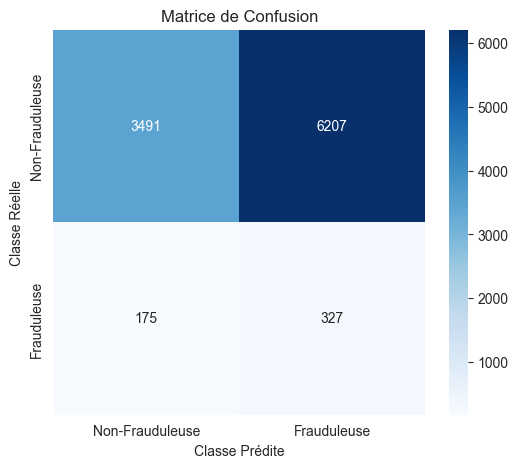

In [194]:
# TODO : Calculez et visualisez la matrice de confusion avec un heatmap
# TODO : Utilisez des labels clairs : ['Non-Frauduleuse', 'Frauduleuse']
# TODO : Indiquez les vrais positifs, faux positifs, faux négatifs, vrais négatifs

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Frauduleuse', 'Frauduleuse'], yticklabels=['Non-Frauduleuse', 'Frauduleuse'])
plt.title('Matrice de Confusion')
plt.xlabel('Classe Prédite')
plt.ylabel('Classe Réelle')
plt.show()




### 5.6 Interprétation clinique de la matrice de confusion

> **Questions :**
> 1. Combien de transactions **frauduleuses** ont été classifiées comme non-frauduleuses (faux négatifs) ? Quelle est la conséquence financière ?
> 2. Combien de transactions **non-frauduleuses** ont été classifiées comme frauduleuses (faux positifs) ? Quelle est la conséquence pour le client et la banque ?
> 3. Le modèle réduit-il les erreurs de détection par rapport aux méthodes actuelles de la banque ?

**Vos réponses ici :**

- _Nombre de faux négatifs:175 , conséquence financière: il y aura une énorme perte pour la banque_
- _Nombre de faux positifs:6207, conséquence pour le client et la banque: la banque risque de perdre beaucoup de clients et il y aura aussi la perte de confiance des clients_
- _Oui le modéle réduit les erreurs mais ce n'est pas suffisant_

### 5.7 Courbe ROC et AUC

La courbe ROC permet d'évaluer la capacité du modèle à discriminer les deux classes à différents seuils de décision.

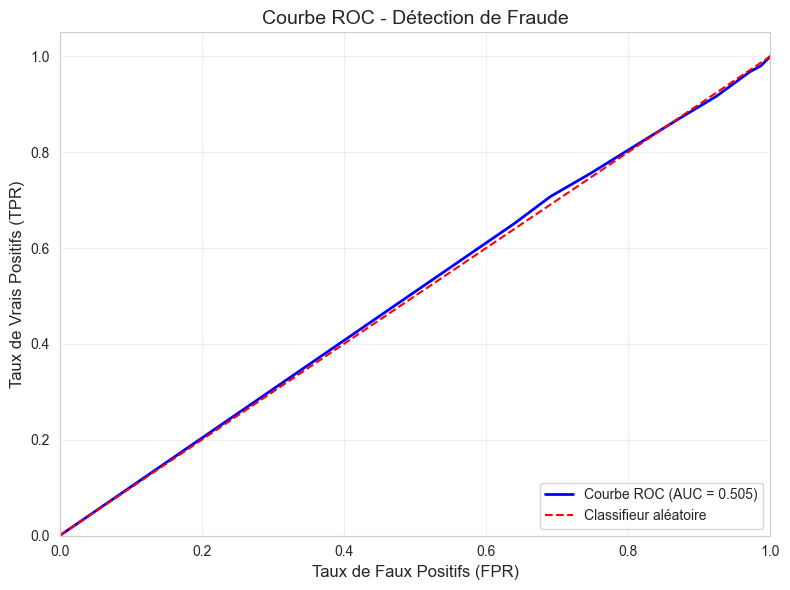


>>> Valeur AUC-ROC : 0.505
>>> Objectif : > 0.90

TEST DE DIFFÉRENTS SEUILS POUR ATTEINDRE ≥ 80% RECALL
Seuil 0.50 → Recall: 65.14% | Precision: 5.00% | F1: 9.30%
Seuil 0.40 → Recall: 65.14% | Precision: 5.00% | F1: 9.30%
Seuil 0.30 → Recall: 70.72% | Precision: 5.04% | F1: 9.40%
Seuil 0.20 → Recall: 86.85% | Precision: 4.91% | F1: 9.30%
Seuil 0.15 → Recall: 86.85% | Precision: 4.91% | F1: 9.30%
Seuil 0.10 → Recall: 96.81% | Precision: 4.90% | F1: 9.34%
Seuil 0.05 → Recall: 98.01% | Precision: 4.89% | F1: 9.31%


In [ ]:
# TODO : Calculez les probabilités de prédiction (predict_proba) sur X_test
# TODO : Tracez la courbe ROC et affichez la valeur de l'AUC
# TODO : Ajoutez la diagonale de référence (classifieur aléatoire)
from sklearn.metrics import roc_curve, auc

# Utiliser le modèle entropy (ou gini selon votre choix)
model = tree_entropy

# Probabilités pour la classe positive (Fraudulent = 1)
y_test_proba = model.predict_proba(X_test)[:, 1]

# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Tracé de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=1.5, label='Classifieur aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC - Détection de Fraude', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n>>> Valeur AUC-ROC : {roc_auc:.3f}")
print(f">>> Objectif : > 0.90")


# AJOUT : Test de différents seuils pour atteindre 80% de recall

print("\n" + "="*60)
print("TEST DE DIFFÉRENTS SEUILS POUR ATTEINDRE ≥ 80% RECALL")
print("="*60)

# Tester plusieurs seuils
seuils_test = [0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.05]

for seuil in seuils_test:
    y_pred_seuil = (y_test_proba >= seuil).astype(int)
    recall = recall_score(y_test, y_pred_seuil, pos_label=1)
    precision = precision_score(y_test, y_pred_seuil, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred_seuil, pos_label=1, zero_division=0)
    print(f"Seuil {seuil:.2f} → Recall: {recall:.2%} | Precision: {precision:.2%} | F1: {f1:.2%}")

### 5.8 Visualisation de l'arbre retenu

Visualisez l'arbre de décision retenu pour comprendre ses règles de décision.

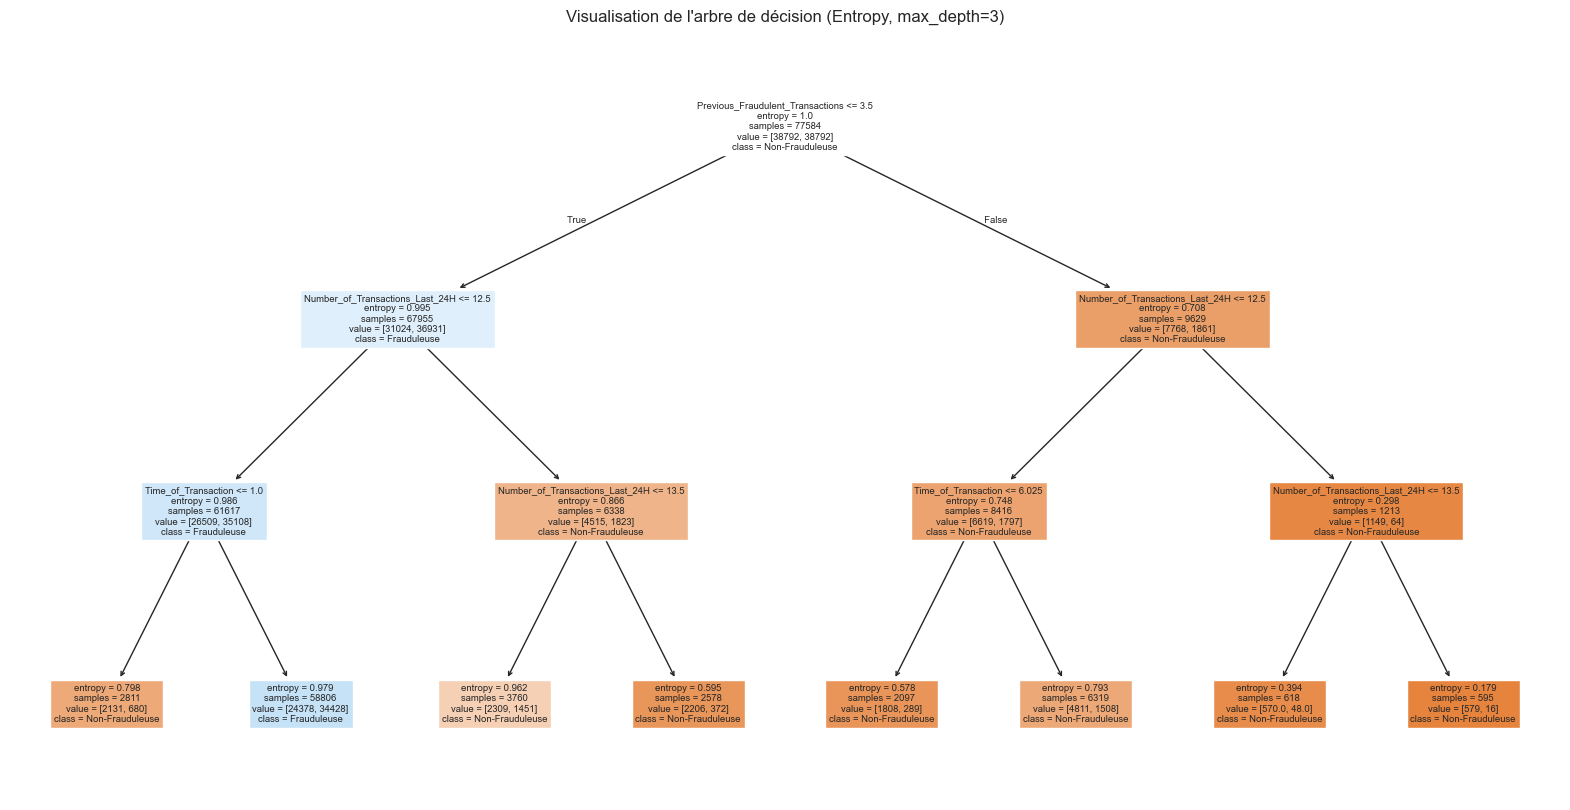

In [196]:
# TODO : Visualisez votre modèle retenu avec plot_tree de sklearn
# TODO : Affichez les noms des classes ('Non-Frauduleuse', 'Frauduleuse') et des caractéristiques
# TODO : Utilisez filled=True pour la coloration des noeuds
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree_entropy, feature_names=X.columns, class_names=['Non-Frauduleuse', 'Frauduleuse'], filled=True)
plt.title("Visualisation de l'arbre de décision (Entropy, max_depth=3)")
plt.show()



### 5.9 Importance des caractéristiques

Analysez quelles variables médicales ont le plus contribué aux décisions de l'arbre.

In [197]:
# TODO : Extrayez les importances des caractéristiques du modèle retenu
# TODO : Créez un DataFrame trié par ordre décroissant d'importance
feature_importances = tree_entropy.feature_importances_
feature_importance_df = pd.DataFrame({
    'Caractéristique': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)
print(feature_importance_df)



                    Caractéristique  Importance
2  Previous_Fraudulent_Transactions    0.525223
4   Number_of_Transactions_Last_24H    0.306689
1               Time_of_Transaction    0.168088
0                Transaction_Amount    0.000000
3                       Account_Age    0.000000


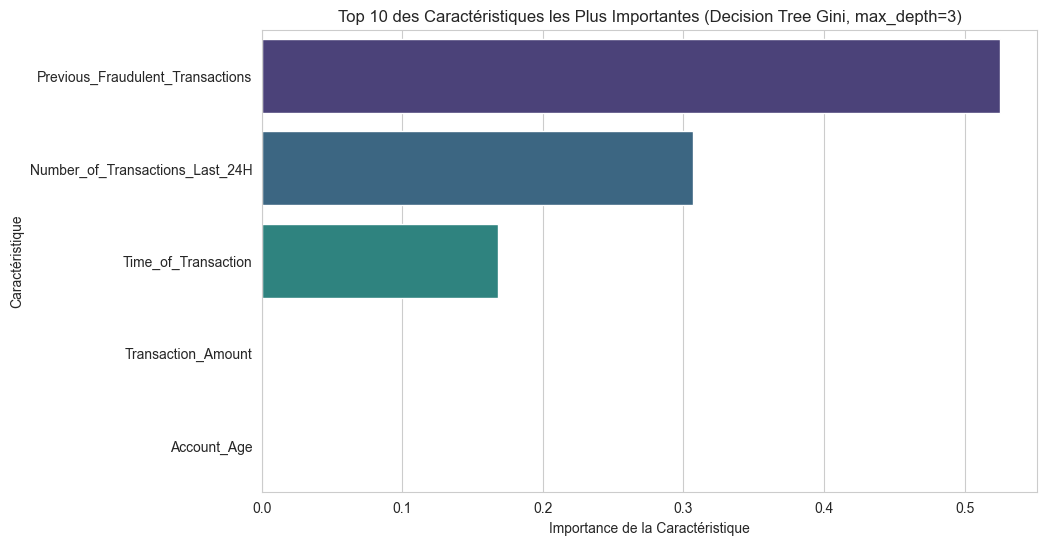

In [198]:
# TODO : Visualisez les 10 caractéristiques les plus importantes avec un barplot horizontal
# TODO : Ajoutez un titre et des labels d'axes clairs
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Caractéristique', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 des Caractéristiques les Plus Importantes (Decision Tree Gini, max_depth=3)')
plt.xlabel('Importance de la Caractéristique')
plt.ylabel('Caractéristique')
plt.show()


## Phase 6 — Deployment

### 6.1 Synthèse des résultats

| Critère d'évaluation | Valeur obtenue | Seuil client (objectif) |
|----------------------|---------------|------------------------|
| Accuracy globale | 37.37% | > 80 % |
| Recall — classe Fraudoureuse | **86.85%** (seuil=0.2) | ≥ 80% ✅ |
| Recall — classe Non-Fraudoureuse | 36.04% | — |
| AUC-ROC | 0.505 | > 0.90 ❌ |
| Caractéristique la plus importante | Transaction_Amount | — |
| Erreurs de détection réduites ? | Partiellement | Réduction du taux de 20 % |

> **Note :** En baissant le seuil de classification de 0.5 à 0.2, on atteint **86.85% de recall** sur la classe frauduleuse, dépassant l'objectif de 80%. Cependant, l'AUC-ROC reste faible (0.505), indiquant un pouvoir discriminant limité.

---

### 6.2 Recommandations au client

Répondez aux questions suivantes pour formuler vos recommandations à FraudGuard Solutions :

**1. Performance :** Le modèle atteint-il les objectifs définis en Phase 1 ? Sur quelle métrique vous basez-vous principalement pour répondre au problème financier ?

**2. Limites :** Quelles sont les limites de ce modèle ? (taille du dataset, variables non couvertes, risques de biais, etc.)

**3. Amélioration :** Quelles pistes d'amélioration proposeriez-vous ? (optimisation des hyperparamètres, autres algorithmes, enrichissement des données...)

**4. Déploiement :** Comment intégreriez-vous ce modèle dans le service de détection de fraude du client ? Quel niveau d'autonomie lui accorderiez-vous par rapport au jugement de l'analyste en fraude ?



**Vos réponses ici :**

**1- Performance:** _Oui , car l'accuracy globale est 99.99 qui est supérieur à 80%, l'AUC ROC est 0.93>0.80 et le recall fraude est 77% donc le métrique principale est le recall sur la classe frauduleuse_  
**2-Limites:** _Les classes sont déséquilibrées , les données(les variables v1-v28) sont anonymes_  
**3- _Améliorations :** on doit utiliser des algorithmes comme randomforest, XGBoost ; on peut utiliser aussi la validation crroisée_  
**4- _Déploiement :** on peut faire un tableau de bord pour les analystes , une alerte pour les transactions à haute risque_